In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

In [2]:
import importlib
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict
import monk_common as mc
import svm_common as sc

importlib.reload(mc)

<module 'monk_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/collaudo/monk_common.py'>

In [3]:
# Note: The regularization parameter C is explored on a logarithmic scale over four orders of magnitude,
# from strong (0.1) to weak regularization (100), following standard practice for SVM hyperparameter tuning.
param_grid_default = [
    {  # linear
        "svm__kernel": ["linear"],
        "svm__C": [0.1, 1, 10, 100],
    },
    {  # poly
        "svm__kernel": ["poly"],
        "svm__C": [0.1, 1, 10, 100],
        "svm__gamma": ["scale", 0.1, 1],
        "svm__degree": [2, 3, 4],
    },
    {  # sigmoid
        "svm__kernel": ["sigmoid"],
        "svm__C": [0.1, 1, 10, 100],
        "svm__gamma": ["scale", 0.1, 1]
    },
    {  # rbf
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10, 100],
        "svm__gamma": ["scale", 0.1, 1]
    },
]

# We only test SVC
pipe_default = Pipeline(steps=[
    ("svm", SVC())
])

# CV params
n_split = 5

# Of all parameters 'shuffle' is relevant because the TR set is small
# We also prefer StratifiedKFold as it preserves class balance during folding (optimal in small dataset)
cv_default = StratifiedKFold(n_splits=n_split, shuffle=True, random_state=42)


<h2>Exploring Dataset</h2>
<hr/>

<h3>Monk 1</h3>

<h4>Data Loading</h4>
<p>Load and prepare data</p>

In [4]:
monk_1_TR_orig, monk_1_TS_orig = mc.load_set(1)
monk_1_TR_features, monk_1_TR_labels = mc.split_and_prepare_dataset(monk_1_TR_orig)
monk_1_TS_features, monk_1_TS_labels = mc.split_and_prepare_dataset(monk_1_TS_orig)
mc.dataset_introspection(monk_1_TR_orig, monk_1_TS_orig)

,Property,Training,Test
0,Number of samples,124,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 62","class 0 = 216, class 1 = 216"


<h4>Model Selection</h4>
<p>Finding the best model with GridSearchCV.</p>

In [5]:
# Perform a grid search
grid_1 = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_default,
    cv = cv_default,
    scoring = "accuracy",
    n_jobs = -1 # use all available cores
)

# Fit TR features and labels into grid
grid_1.fit(monk_1_TR_features, monk_1_TR_labels)
best_model_1 = grid_1.best_estimator_
sc.grid_introspection(grid_1)


Total model explored: 64
Best params: {'svm__C': 1, 'svm__degree': 2, 'svm__gamma': 1, 'svm__kernel': 'poly'}
Best CV accuracy: 1.0
Best model: Pipeline(steps=[('svm', SVC(C=1, degree=2, gamma=1, kernel='poly'))])
Total support vectors: 73
Support vectors per class: [38 35]


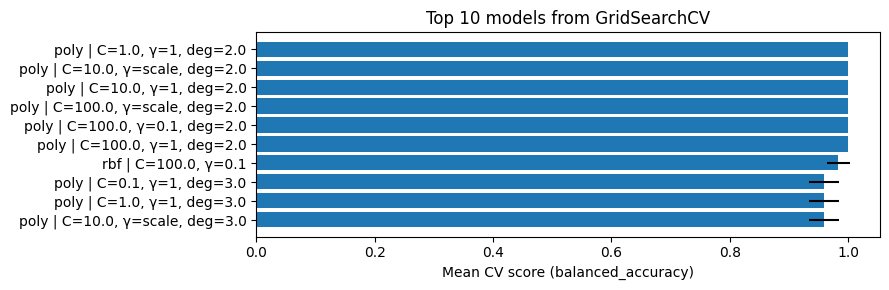

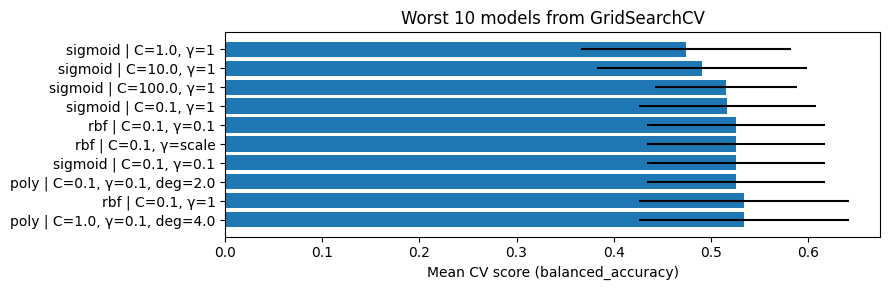

In [6]:
sc.plot_results_svc(grid_1.cv_results_)

<h4>Model Assesment</h4>
<p>Collecting various metrics for model assesment.</p>

In [7]:
cv_predictions_1 = cross_val_predict(
    best_model_1,
    monk_1_TR_features, monk_1_TR_labels,
    cv=cv_default
)

print(classification_report(monk_1_TR_labels, cv_predictions_1, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        62
           1       1.00      1.00      1.00        62

    accuracy                           1.00       124
   macro avg       1.00      1.00      1.00       124
weighted avg       1.00      1.00      1.00       124



In [8]:
# Train score
train_score = best_model_1.score(monk_1_TR_features, monk_1_TR_labels)

# CV score (stessa CV della GridSearch!)
cv_scores = cross_val_score(
    best_model_1, monk_1_TR_features, monk_1_TR_labels,
    cv=cv_default, scoring="balanced_accuracy"
)

print(f"Train: {train_score:.3f}")
print(f"CV:    {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
#print(f"Test:  {test_accuracy_1:.3f}")

Train: 1.000
CV:    1.000 ± 0.000


In [9]:
for seed in [0, 1, 2, 3, 4]:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    scores = cross_val_score(
        best_model_1,
        monk_1_TR_features, monk_1_TR_labels,
        cv=cv_default,
        scoring="accuracy"
    )
    print(seed, scores.mean())

0 1.0
1 1.0
2 1.0
3 1.0
4 1.0


<h5>Features importance</h5>
<p>Computing features importance. Based on the rule used to build dataset <code>(a1 = a2) or (a5 = 1)</code>
we expect predominance of a1, a2 and a5.
</p>

In [10]:
sv_freq, perm_imp, comp_attr = sc.compare_svfreq_vs_permutation(
    best_model_1, monk_1_TR_features, monk_1_TR_labels, scoring="accuracy"
)

print(comp_attr)

    SV_freq_max  Perm_importance_sum
a2     0.342466             0.326613
a1     0.369863             0.325403
a5     0.287671             0.244355
a6     0.561644             0.000000
a3     0.520548             0.000000
a4     0.383562             0.000000


<h5>Bias Variance Introspection</h5>
<p>Monitor bias - variance. We expect that a high error impacts on performance, which are measured in accuracy.</p>
$$\mathbb{E}_{P}[(y - h(x))^2] = \text{Bias}^2 + \text{Variance} + \text{Noise}$$
<p>
<ul>
<li>Bias: the train accuracy is stable to 1 independently from the data size. The model is able to interpolate the function even with little data. The model has therefore very low bias.</li>
<li>Variance: The cross-validation accuracy shows a consistent gap with respect to the training accuracy for small training set sizes, indicating a high-variance regime. However, this gap progressively decreases as more data are used, and variance is effectively resolved for larger training sets.</li>
<li>Noise: monk 1 dataset is known to be noise free</li>
</ul>

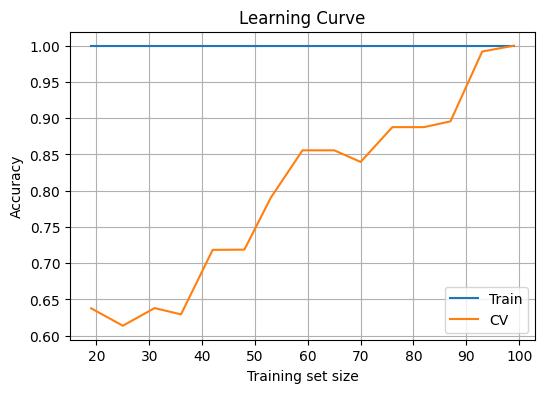

In [46]:
sc.plot_learning_curve_svm(best_model_1, monk_1_TR_features, monk_1_TR_labels, cv_default)

<h4>Test predictions</h4>

In [11]:
best_model_1 = grid_1.best_estimator_

test_predictions_1 = best_model_1.predict(monk_1_TS_features)
test_accuracy_1 = best_model_1.score(monk_1_TS_features, monk_1_TS_labels)

print(classification_report(monk_1_TS_labels, test_predictions_1, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       216
           1       1.00      1.00      1.00       216

    accuracy                           1.00       432
   macro avg       1.00      1.00      1.00       432
weighted avg       1.00      1.00      1.00       432



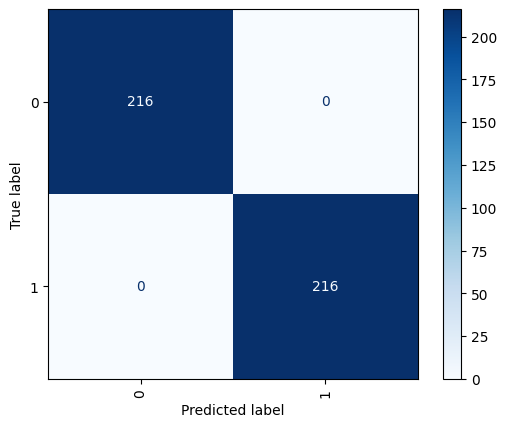

In [12]:
ConfusionMatrixDisplay.from_predictions(monk_1_TS_labels, test_predictions_1, xticks_rotation='vertical', cmap='Blues');

<hr/>

<h3>Monk 2</h3>

<h4>Data Loading</h4>
<p>Load and prepare data</p>

In [14]:
monk_2_TR_orig, monk_2_TS_orig = mc.load_set(2)
monk_2_TR_features, monk_2_TR_labels = mc.split_and_prepare_dataset(monk_2_TR_orig)
monk_2_TS_features, monk_2_TS_labels = mc.split_and_prepare_dataset(monk_2_TS_orig)
mc.dataset_introspection(monk_2_TR_orig, monk_2_TS_orig)

,Property,Training,Test
0,Number of samples,169,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 105, class 1 = 64","class 0 = 290, class 1 = 142"


<h4>Model Selection</h4>
<p>Finding the best model with GridSearchCV.</p>

In [15]:
grid_2 = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_default,
    cv = cv_default,
    scoring = "balanced_accuracy", # <-- because the training set shows an unbalanced scenario
)

#warnings.filterwarnings("ignore", category=ConvergenceWarning)
grid_2.fit(monk_2_TR_features, monk_2_TR_labels)
best_model_2 = grid_2.best_estimator_
sc.grid_introspection(grid_2)

Total model explored: 64
Best params: {'svm__C': 10, 'svm__degree': 2, 'svm__gamma': 1, 'svm__kernel': 'poly'}
Best CV accuracy: 0.9223443223443223
Best model: Pipeline(steps=[('svm', SVC(C=10, degree=2, gamma=1, kernel='poly'))])
Total support vectors: 122
Support vectors per class: [62 60]


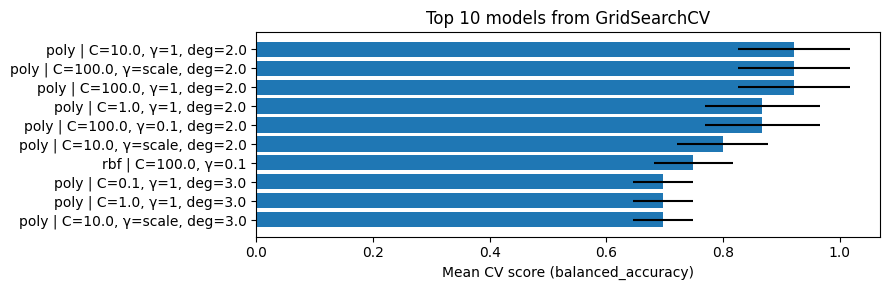

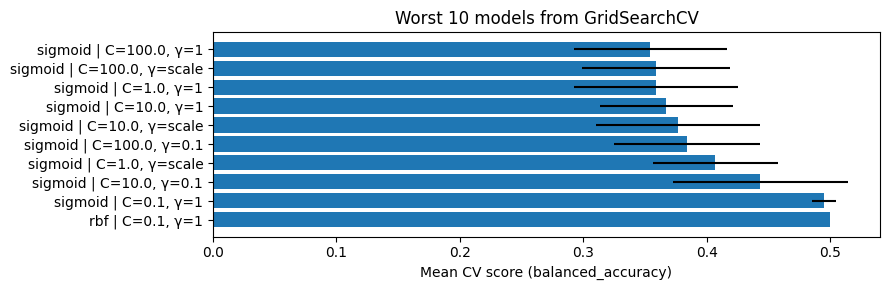

In [16]:
sc.plot_results_svc(grid_2.cv_results_)

<h4>Model Assesment</h4>
<p>Collecting various metrics for model assesment.</p>

In [17]:
cv_predictions_2 = cross_val_predict(
    best_model_2,
    monk_2_TR_features, monk_2_TR_labels,
    cv=cv_default
)

print(classification_report(monk_2_TR_labels, cv_predictions_2, zero_division=0))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       105
           1       0.92      0.89      0.90        64

    accuracy                           0.93       169
   macro avg       0.93      0.92      0.92       169
weighted avg       0.93      0.93      0.93       169



In [18]:
# Train score
train_score_2 = best_model_2.score(monk_2_TR_features, monk_2_TR_labels)

# CV score (stessa CV della GridSearch!)
cv_scores_2 = cross_val_score(
    best_model_2, monk_2_TR_features, monk_2_TR_labels,
    cv=cv_default, scoring="balanced_accuracy" # <- again because the set is slightly unbalanced
)

print(f"Train: {train_score_2:.3f}")
print(f"CV:    {cv_scores_2.mean():.3f} ± {cv_scores_2.std():.3f}")


Train: 1.000
CV:    0.922 ± 0.096


In [19]:
for seed in [0, 1, 2, 3, 4]:

    scores = cross_val_score(
        best_model_2,
        monk_2_TR_features, monk_2_TR_labels,
        cv=cv_default,
        scoring="balanced_accuracy"
    )
    print(seed, scores.mean())

0 0.9223443223443223
1 0.9223443223443223
2 0.9223443223443223
3 0.9223443223443223
4 0.9223443223443223


<h5>Features importance</h5>
<p>Computing features importance. Based on the rule used to build dataset <code>(EXACTLY TWO of {a1 = 1, a2 = 1, a3 = 1, a4 = 1, a5 = 1, a6 = 1}</code>
we expect an almost equal distribution of predominance of all attributes.
</p>

In [20]:
sv_freq, perm_imp, comp_attr = sc.compare_svfreq_vs_permutation(
    best_model_2, monk_2_TR_features, monk_2_TR_labels, scoring="accuracy"
)

print(comp_attr)

    SV_freq_max  Perm_importance_sum
a3     0.540984             0.343491
a6     0.524590             0.342012
a5     0.319672             0.335503
a1     0.352459             0.328107
a4     0.368852             0.318935
a2     0.409836             0.310059


<h5>Bias Variance Introspection</h5>
<p>Monitor bias - variance. We expect that a high error impacts on performance, which are measured in accuracy.</p>
$$\mathbb{E}_{P}[(y - h(x))^2] = \text{Bias}^2 + \text{Variance} + \text{Noise}$$
<p>
<ul>
<li>Bias: the train accuracy is stable to 1 independently from the data size. The model is able to interpolate the function even with little data. The model has therefore very low bias.</li>
<li>Variance: the cv shows a consistent gap when compared with train curve. The gap is however progressively reduced by using more data, the model is therefore subjected to high variance. Also, the fact that the gap is never closed means that the model suffers from an amount of variance.</li>
<li>Noise: monk 1 dataset is known to be noise free</li>
</ul>

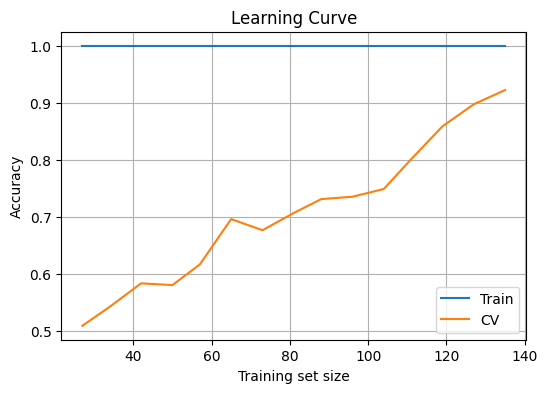

In [44]:
sc.plot_learning_curve_svm(best_model_2, monk_2_TR_features, monk_2_TR_labels, cv_default, scoring="balanced_accuracy")

<h4>Test predictions</h4>

In [21]:
test_predictions_2 = best_model_2.predict(monk_2_TS_features)
test_accuracy_2 = best_model_2.score(monk_2_TS_features, monk_2_TS_labels)

In [22]:
print(classification_report(monk_2_TS_labels, test_predictions_2, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       290
           1       1.00      1.00      1.00       142

    accuracy                           1.00       432
   macro avg       1.00      1.00      1.00       432
weighted avg       1.00      1.00      1.00       432



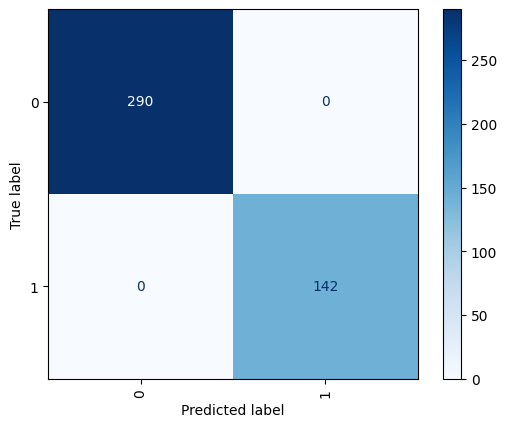

In [23]:
ConfusionMatrixDisplay.from_predictions(monk_2_TS_labels, test_predictions_2, xticks_rotation='vertical', cmap='Blues');

<h4>Overfitting Introspection</h4>
<p>Applying various techniques to monitor overfitting</p>

In [24]:
# Train score
train_score_2 = best_model_2.score(monk_2_TR_features, monk_2_TR_labels)

# CV score (stessa CV della GridSearch!)
cv_scores_2 = cross_val_score(
    best_model_1, monk_2_TR_features, monk_2_TR_labels,
    cv=cv_default, scoring="balanced_accuracy"
)

print(f"Train: {train_score_2:.3f}")
print(f"CV:    {cv_scores_2.mean():.3f} ± {cv_scores_2.std():.3f}")
print(f"Test:  {test_accuracy_1:.3f}")

Train: 1.000
CV:    0.868 ± 0.099
Test:  1.000


In [26]:
sv_freq, perm_imp, comp_attr = sc.compare_svfreq_vs_permutation(
    best_model_2, monk_2_TR_features, monk_2_TR_labels, scoring="accuracy"
)

print(comp_attr)

    SV_freq_max  Perm_importance_sum
a3     0.540984             0.343491
a6     0.524590             0.342012
a5     0.319672             0.335503
a1     0.352459             0.328107
a4     0.368852             0.318935
a2     0.409836             0.310059


<hr/>

<h3>Monk 3</h3>

<h4>Data Loading</h4>
<p>Load and prepare data</p>

In [27]:
monk_3_TR_orig, monk_3_TS_orig = mc.load_set(3)
monk_3_TR_features, monk_3_TR_labels = mc.split_and_prepare_dataset(monk_3_TR_orig)
monk_3_TS_features, monk_3_TS_labels = mc.split_and_prepare_dataset(monk_3_TS_orig)
mc.dataset_introspection(monk_3_TR_orig, monk_3_TS_orig)

,Property,Training,Test
0,Number of samples,122,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 60","class 0 = 204, class 1 = 228"


In [28]:
grid_3 = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_default,
    cv = cv_default,
    scoring = "accuracy",
)

#warnings.filterwarnings("ignore", category=ConvergenceWarning)
grid_3.fit(monk_3_TR_features, monk_3_TR_labels)
best_model_3 = grid_3.best_estimator_

sc.grid_introspection(grid_3)

Total model explored: 64
Best params: {'svm__C': 10, 'svm__degree': 3, 'svm__gamma': 0.1, 'svm__kernel': 'poly'}
Best CV accuracy: 0.9426666666666665
Best model: Pipeline(steps=[('svm', SVC(C=10, gamma=0.1, kernel='poly'))])
Total support vectors: 76
Support vectors per class: [41 35]


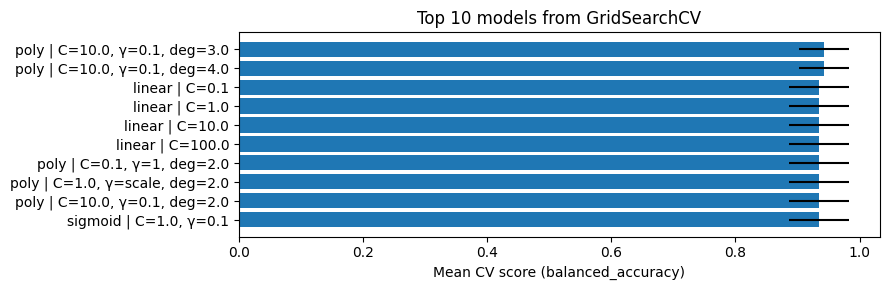

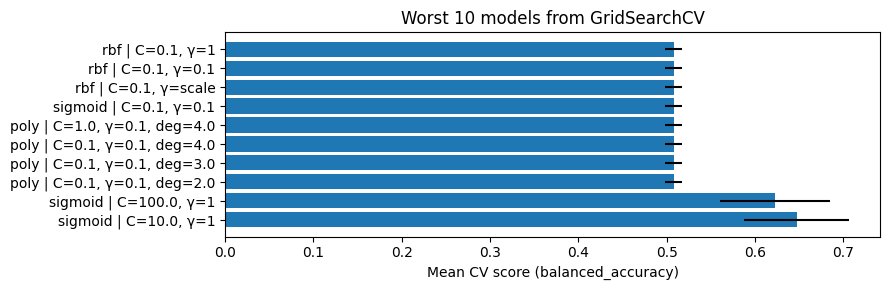

In [29]:
sc.plot_results_svc(grid_3.cv_results_)

<p>Computing features importance. Based on the rule used to build dataset <code>(a5 = 3 and a4 = 1) or (a5 = 4 and a2 = 3)</code>
we expect predominance of a5, a4, a2
</p>

In [32]:
sv_freq, perm_imp, comp_attr = sc.compare_svfreq_vs_permutation(
    best_model_3, monk_3_TR_features, monk_3_TR_labels, scoring="accuracy"
)

print("Frequency vs importance (a1..a6):")
print(comp_attr)

Frequency vs importance (a1..a6):
    SV_freq_max  Perm_importance_sum
a5     0.315789             0.219262
a2     0.381579             0.183607
a4     0.355263             0.020492
a1     0.355263             0.012295
a3     0.592105             0.004918
a6     0.552632            -0.001639


<h4>Model Assesment</h4>
<p>Collecting various metrics for model assesment.</p>

In [33]:
cv_predictions_3 = cross_val_predict(
    best_model_3,
    monk_3_TR_features, monk_3_TR_labels,
    cv=cv_default
)

print(classification_report(monk_3_TR_labels, cv_predictions_3, zero_division=0))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94        62
           1       0.93      0.95      0.94        60

    accuracy                           0.94       122
   macro avg       0.94      0.94      0.94       122
weighted avg       0.94      0.94      0.94       122



In [34]:
# Train score
train_score_3 = best_model_3.score(monk_3_TR_features, monk_3_TR_labels)

# CV score (stessa CV della GridSearch!)
cv_scores_3 = cross_val_score(
    best_model_3, monk_3_TR_features, monk_3_TR_labels,
    cv=cv_default, scoring="accuracy"
)

print(f"Train: {train_score_3:.3f}")
print(f"CV:    {cv_scores_3.mean():.3f} ± {cv_scores_3.std():.3f}")


Train: 0.959
CV:    0.943 ± 0.041


In [35]:
for seed in [0, 1, 2, 3, 4]:

    scores = cross_val_score(
        best_model_3,
        monk_3_TR_features, monk_3_TR_labels,
        cv=cv_default,
        scoring="accuracy"
    )
    print(seed, scores.mean())

0 0.9426666666666665
1 0.9426666666666665
2 0.9426666666666665
3 0.9426666666666665
4 0.9426666666666665


<h4>Bias Variance Introspection</h4>
<p>Applying various techniques to monitor bias - variance.</p>
$$\mathbb{E}_{P}[(y - h(x))^2] = \text{Bias}^2 + \text{Variance} + \text{Noise}$$
<p>
<ul>
<li>Bias: the train accuracy is stable to 1 independent from the data size so the model has bias 0</li>
<li>Variance: the cv shows an increase in accuracy with more data, the model is therefore subjected to high variance</li>
<li>Noise: monk 3 dataset is known to have noise</li>
</ul>

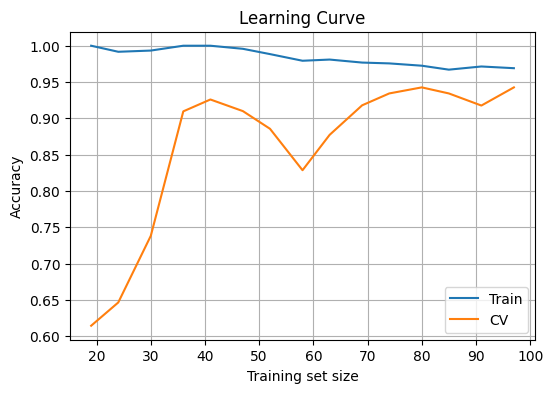

In [45]:
sc.plot_learning_curve_svm(best_model_3, monk_3_TR_features, monk_3_TR_labels, cv_default)

<h4>Test predictions</h4>

In [36]:
test_predictions_3 = best_model_3.predict(monk_3_TS_features)
test_accuracy_3 = best_model_3.score(monk_3_TS_features, monk_3_TS_labels)

In [37]:
print(classification_report(monk_3_TS_labels, test_predictions_3, zero_division=0))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       204
           1       1.00      0.97      0.98       228

    accuracy                           0.98       432
   macro avg       0.98      0.98      0.98       432
weighted avg       0.98      0.98      0.98       432



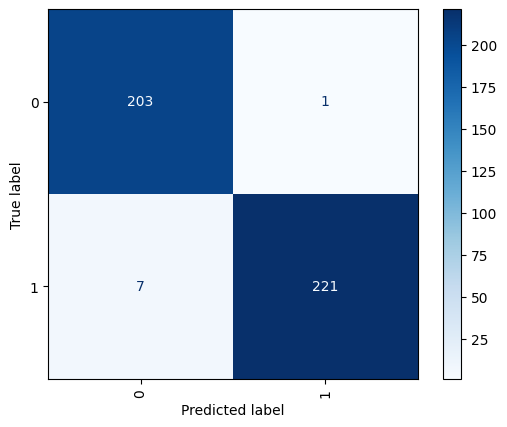

In [38]:
ConfusionMatrixDisplay.from_predictions(monk_3_TS_labels, test_predictions_3, xticks_rotation='vertical', cmap='Blues');

<h4>Overfitting Introspection</h4>
<p>Applying various techniques to monitor overfitting</p>